Hamiltonian-ODE Dynamic Graph Learning (3D Visualization Ready)
1. データ読み込み開始...
2. 埋め込みベクトルを結合中...
  10000件処理済み...
  20000件処理済み...
  30000件処理済み...
  40000件処理済み...
✓ 前処理完了: 19389 件
Nodes: 21834, Corps: 2450, Dim: 1088

>>> Training Started...
Epoch 01 | Loss: 61.2683 | MRR: 0.0532 | Consist: 0.980
Epoch 02 | Loss: 48.7574 | MRR: 0.0540 | Consist: 0.983
Epoch 03 | Loss: 46.0875 | MRR: 0.0538 | Consist: 0.986
Epoch 04 | Loss: 50.1375 | MRR: 0.0597 | Consist: 0.984
Epoch 05 | Loss: 49.3841 | MRR: 0.0457 | Consist: 0.977
Epoch 06 | Loss: 48.3354 | MRR: 0.0586 | Consist: 0.975
Epoch 07 | Loss: 46.0649 | MRR: 0.0534 | Consist: 0.976
Epoch 08 | Loss: 41.5530 | MRR: 0.0596 | Consist: 0.967
Epoch 09 | Loss: 39.4436 | MRR: 0.0645 | Consist: 0.964
Epoch 10 | Loss: 37.6234 | MRR: 0.0604 | Consist: 0.961
Epoch 11 | Loss: 36.7591 | MRR: 0.0518 | Consist: 0.954
Epoch 12 | Loss: 35.1428 | MRR: 0.0519 | Consist: 0.950
Epoch 13 | Loss: 35.3231 | MRR: 0.0492 | Consist: 0.949
Epoch 14 | Loss: 34.4273 | MRR

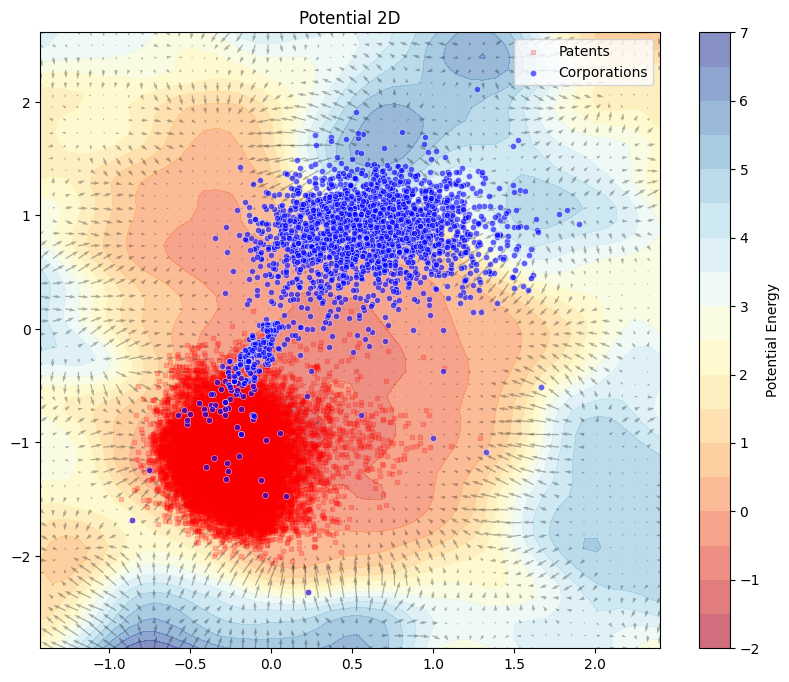

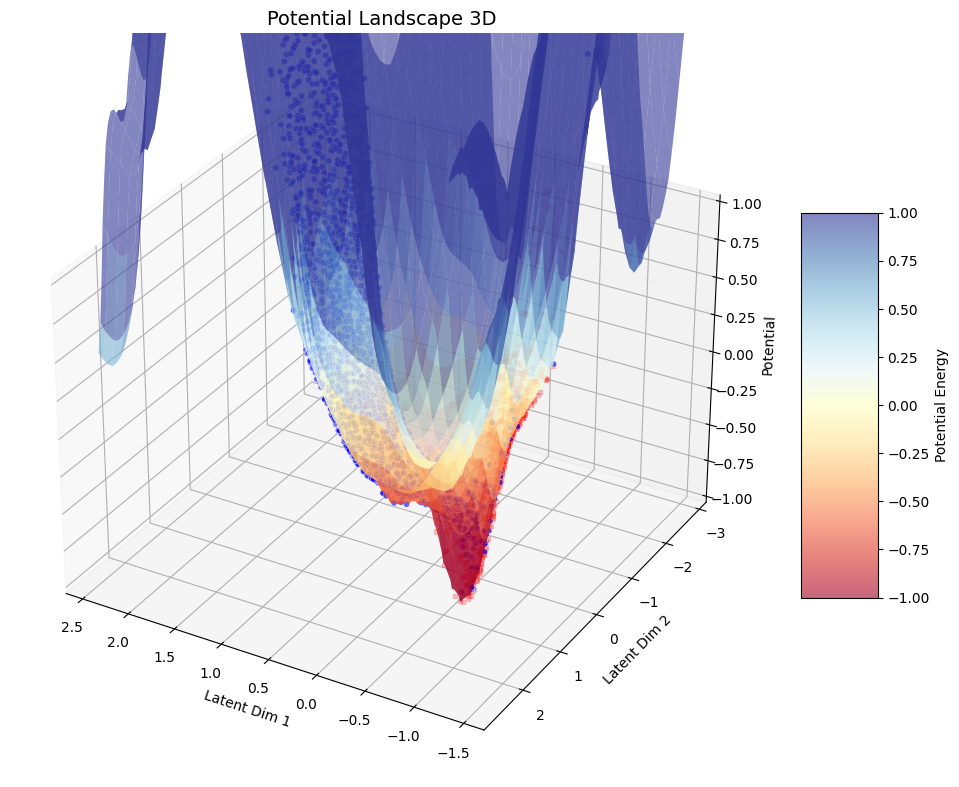

In [10]:
import time
import pandas as pd
import numpy as np
import ast
import re
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GATConv
from torchdiffeq import odeint_adjoint as odeint
from torch.optim.lr_scheduler import ReduceLROnPlateau
import warnings
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # 3Dプロット用

# 基本設定
warnings.filterwarnings('ignore')
torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ============================================================
# 1. データ前処理
# ============================================================
def safe_parse_embedding(x):
    """埋め込みベクトルの文字列を安全にパースする"""
    if pd.isna(x) or x == "":
        return None
    if isinstance(x, (list, np.ndarray)):
        return np.array(x, dtype=np.float32)
    if isinstance(x, str):
        try:
            s = re.sub(r'[\[\]\n]', '', x)
            s = s.replace(',', ' ')
            vals = np.array([float(v) for v in s.split() if v], dtype=np.float32)
            return vals if len(vals) > 0 else None
        except Exception:
            return None
    return None

def preprocess_data(file_path):
    print("1. データ読み込み開始...")
    try:
        df = pd.read_csv(file_path)
    except FileNotFoundError:
        print(f"エラー: ファイル '{file_path}' が見つかりません。")
        return pd.DataFrame()

    print("2. 埋め込みベクトルを結合中...")
    combined_vectors = []
    valid_indices = []
    
    for i, row in df.iterrows():
        desc = safe_parse_embedding(row.get('description_embedding', ''))
        meta = safe_parse_embedding(row.get('metadata_embedding', ''))
        
        if desc is not None and meta is not None:
            if len(desc) > 0 and len(meta) > 0:
                combined_vectors.append(np.concatenate([desc, meta]))
                valid_indices.append(i)
        
        if i % 10000 == 0 and i > 0:
            print(f"  {i}件処理済み...")

    if not combined_vectors:
        print("警告: 有効なベクトルデータがありません。")
        return pd.DataFrame()

    df = df.iloc[valid_indices].copy()
    df['combined_vector'] = combined_vectors
    
    def parse_corp(x):
        try:
            return ast.literal_eval(x) if isinstance(x, str) else x
        except:
            return [x] if isinstance(x, str) else x
    
    if "corporation" in df.columns:
        df["corporation"] = df["corporation"].apply(parse_corp)
        df["corporation"] = df["corporation"].apply(lambda x: x if isinstance(x, list) else [])
    
    if "year_month" in df.columns:
        df['year_month'] = pd.to_datetime(df['year_month'], errors='coerce')
        df = df.dropna(subset=['year_month'])
        df = df[(df['year_month'] >= '2010-01-01') & (df['year_month'] <= '2020-12-31')]
    
    print(f"✓ 前処理完了: {len(df)} 件")
    return df

# ============================================================
# 2. モデルコンポーネント定義
# ============================================================

# --- GAT Encoder ---
class SharedVGAEEncoder(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_channels * 2, heads=2, concat=False)
        self.conv2 = GATConv(hidden_channels * 2, hidden_channels, heads=2, concat=False)
        self.conv3 = GATConv(hidden_channels, hidden_channels, heads=1, concat=False)
        self.conv_mu = GATConv(hidden_channels, out_channels, heads=1, concat=False)
        self.conv_logvar = GATConv(hidden_channels, out_channels, heads=1, concat=False)
        self.dropout = nn.Dropout(0.2)
        self.batch_norm1 = nn.BatchNorm1d(hidden_channels * 2)
        self.batch_norm2 = nn.BatchNorm1d(hidden_channels)

    def forward(self, x, edge_index):
        x = F.relu(self.batch_norm1(self.conv1(x, edge_index)))
        x = self.dropout(x)
        x = F.relu(self.batch_norm2(self.conv2(x, edge_index)))
        x = self.dropout(x)
        x = F.relu(self.conv3(x, edge_index))
        return self.conv_mu(x, edge_index), self.conv_logvar(x, edge_index)

# --- PotentialNet (With Grid Computation) ---
class PotentialNet(nn.Module):
    def __init__(self, latent_dim, hidden_dim):
        super().__init__()
        # Random Fourier Features (RFF) 用の周波数行列
        self.B = nn.Parameter(torch.randn(latent_dim, hidden_dim // 2) * 3.0, requires_grad=False)

        input_features = hidden_dim # sin/cos projectionにより次元が決定
        
        self.net = nn.Sequential(
            nn.Linear(input_features, hidden_dim * 2),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, z):
        # 座標 z を高周波空間へ射影
        proj = torch.matmul(z, self.B)
        x = torch.cat([torch.sin(proj), torch.cos(proj)], dim=-1)
        return self.net(x)

    def compute_potential_grid(self, x_range, y_range, resolution=50, device='cpu'):
        """グリッド上でポテンシャルを計算"""
        x = torch.linspace(x_range[0], x_range[1], resolution)
        y = torch.linspace(y_range[0], y_range[1], resolution)
        X, Y = torch.meshgrid(x, y, indexing='ij')
        
        # モデル入力用にフラット化
        grid_points = torch.stack([X.flatten(), Y.flatten()], dim=1).to(device)
        
        # ポテンシャル計算
        model_device = next(self.parameters()).device
        with torch.no_grad():
            potentials = self.forward(grid_points.to(model_device))
        
        return (
            X.cpu().numpy(), 
            Y.cpu().numpy(), 
            potentials.view(resolution, resolution).cpu().numpy()
        )

# --- GradientODEFunc (With Gradient Field Computation) ---
class GradientODEFunc(nn.Module):
    def __init__(self, potential_net):
        super().__init__()
        self.potential_net = potential_net
        self.scale = nn.Parameter(torch.tensor(0.1))

    def forward(self, t, z):
        # 勾配フロー: dz/dt = -grad(Phi)
        with torch.set_grad_enabled(True):
            z_in = z.detach().requires_grad_(True)
            phi = self.potential_net(z_in)
            grad_z = torch.autograd.grad(phi.sum(), z_in, create_graph=True)[0]
        
        # tanhで勾配の大きさを制限し、学習を安定化
        return - torch.tanh(self.scale) * grad_z
    
    def compute_gradient_field(self, X, Y, device='cpu'):
        """グリッド上で勾配ベクトル場を計算"""
        grid_points = torch.tensor(
            np.stack([X.flatten(), Y.flatten()], axis=1), 
            dtype=torch.float32, device=device
        )
        grid_points.requires_grad_(True)
        
        phi = self.potential_net(grid_points)
        gradients = torch.autograd.grad(phi.sum(), grid_points, create_graph=False)[0]
        
        # Hamiltonian/Gradient Flowにおける「移動方向」は -gradient
        grad_x = gradients[:, 0].view(X.shape).cpu().numpy()
        grad_y = gradients[:, 1].view(X.shape).cpu().numpy()
        
        return grad_x, grad_y

class GradientNeuralODEPredictor(nn.Module):
    def __init__(self, latent_dim, hidden_dim):
        super().__init__()
        self.potential_net = PotentialNet(latent_dim, hidden_dim)
        self.ode_func = GradientODEFunc(self.potential_net)

    def forward(self, z_current, delta_t=1.0):
        t_span = torch.tensor([0., delta_t], device=z_current.device)
        # odeintで積分し、最後の時刻の状態を返す
        z_future = odeint(
            self.ode_func, z_current, t_span,
            method='dopri5', rtol=1e-3, atol=1e-3
        )[-1]
        return z_future

# ============================================================
# 3. 統合モデル (UnifiedVGAE)
# ============================================================
class UnifiedVGAE(nn.Module):
    def __init__(self, num_nodes, num_corps, input_dim, hidden_dim=256,
                 latent_dim=2, sequence_length=3):
        super().__init__()
        self.num_nodes = num_nodes
        self.num_corps = num_corps
        self.latent_dim = latent_dim
        
        # 企業用埋め込み
        self.corp_embeddings = nn.Embedding(num_corps, input_dim)
        nn.init.normal_(self.corp_embeddings.weight, mean=0.0, std=0.05)
        
        self.encoder = SharedVGAEEncoder(input_dim, hidden_dim, latent_dim)
        self.temporal_predictor = GradientNeuralODEPredictor(latent_dim, hidden_dim)

        self.link_predictor = nn.Sequential(
            nn.Linear(latent_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, 1)
        )

    def get_node_features(self, x, node_indices=None):
        features = x.clone()
        if node_indices is None:
            node_indices = torch.arange(self.num_nodes, device=x.device)
        corp_idx = node_indices[node_indices < self.num_corps]
        if corp_idx.numel() > 0:
            features[corp_idx] = self.corp_embeddings(corp_idx)
        return features

    def encode(self, x, edge_index, node_indices=None):
        x_features = self.get_node_features(x, node_indices)
        mu, logvar = self.encoder(x_features, edge_index)
        z = self.reparameterize(mu, logvar)
        return z, mu, logvar

    def reparameterize(self, mu, logvar):
        if self.training:
            return mu + torch.randn_like(logvar) * torch.exp(0.5 * logvar)
        return mu

    def decode(self, z, edge_index):
        z_src = z[edge_index[0]]
        z_dst = z[edge_index[1]]
        # === 変更前 (MLP) ===
        # return torch.sigmoid(self.link_predictor(torch.cat([z_src, z_dst], dim=-1))).squeeze()
        # === 変更後 (内積: Inner Product) ===
        # 内積が大きい(=角度が近くベクトルが長い)ほど確率が高くなる
        return torch.sigmoid((z_src * z_dst).sum(dim=1))
    
    def predict_future(self, z_history_list):
        # 最新の潜在変数からODEで未来へ飛ばす
        return self.temporal_predictor(z_history_list[-1])

# ============================================================
# 4. 損失関数と補助関数
# ============================================================
def sample_hard_negatives_v2(model, z, active_corps, active_patents, 
                             pos_set, historical_edges, num_samples=1000):
    if len(active_corps) == 0 or len(active_patents) == 0:
        return None
    
    neg_edges = []
    # ランダム候補生成
    cand_c = active_corps[torch.randint(0, len(active_corps), (num_samples * 5,))]
    cand_p = active_patents[torch.randint(0, len(active_patents), (num_samples * 5,))]

    # 距離計算 (近いのにリンクがないペアを探す)
    dists = torch.norm(z[cand_c] - z[cand_p], dim=1)
    sorted_indices = torch.argsort(dists)
    
    for idx in sorted_indices:
        c, p = cand_c[idx].item(), cand_p[idx].item()
        edge = (c, p)
        if edge not in pos_set and edge not in historical_edges:
            neg_edges.append([c, p])
            if len(neg_edges) >= num_samples:
                break
                
    if not neg_edges:
        return None
    return torch.tensor(neg_edges, dtype=torch.long, device=z.device).t().contiguous()

def compute_loss_standardized(model, data_t, data_t1, num_corps, z_history_for_prediction,
                              historical_edges, beta=0.01, pos_weight=5.0, 
                              latent_pred_weight=1.0, future_link_weight=10.0,
                              potential_weight=10.0, repulsion_weight=5.0): # potential_weight 5.0 -> 5.0に変更
    device = data_t.x.device
    node_indices = torch.arange(model.num_nodes, device=device)
    patent_mask = (node_indices >= num_corps) & data_t.active_mask
    
    # 1. エンコード
    z_t, mu_t, logvar_t = model.encode(data_t.x, data_t.edge_index)
    
    # 2. 再構成損失
    pos_edge_index = data_t.edge_index
    active_corps = torch.unique(pos_edge_index[0][pos_edge_index[0] < num_corps])
    active_patents = torch.unique(pos_edge_index[1][pos_edge_index[1] >= num_corps])
    pos_set = set(tuple(p.tolist()) for p in pos_edge_index.t())
    
    neg_edge_index = sample_hard_negatives_v2(model, z_t, active_corps, active_patents, 
                                                pos_set, historical_edges, num_samples=500)
    
    recon_loss = torch.tensor(0.0, device=device)
    if neg_edge_index is not None:
        pos_pred = model.decode(z_t, pos_edge_index)
        neg_pred = model.decode(z_t, neg_edge_index)
        # ハブ対策（次数重み付け）
        node_degrees = torch.zeros(model.num_nodes, device=device)
        node_degrees.index_add_(0, data_t.edge_index.view(-1), torch.ones(data_t.edge_index.numel(), device=device))
        edge_rarity = 1.0 / torch.log(node_degrees[pos_edge_index[0]] * node_degrees[pos_edge_index[1]] + 1e-15)
        
        recon_loss = -(torch.log(pos_pred + 1e-15) * edge_rarity).mean() * pos_weight \
                     - torch.log(1 - neg_pred + 1e-15).mean()

    # KL損失
    kl_loss = -0.5 * torch.mean(1 + logvar_t[data_t.active_mask] - mu_t[data_t.active_mask].pow(2) - logvar_t[data_t.active_mask].exp())

    # 3. ポテンシャル学習 (人気の特許＝深い谷)
    potential_loss = torch.tensor(0.0, device=device)
    unique_patents, counts = torch.unique(data_t.edge_index[1], return_counts=True)
    has_potential = hasattr(model.temporal_predictor, 'potential_net')
    
    if potential_weight > 0 and has_potential:
        unique_patents, counts = torch.unique(data_t.edge_index[1], return_counts=True)
        if unique_patents.numel() > 0:
            target_phi = torch.zeros(model.num_nodes, 1, device=device)
            ranks = torch.argsort(torch.argsort(counts.float())).float()
            # 人気があるほど -1.0 (谷)、ないほど 1.0 (山)
            normalized_target = 1.0 - (ranks / (ranks.max() + 1e-9)) * 2.0
            target_phi[unique_patents] = normalized_target.view(-1, 1)
            
            predicted_phi = model.temporal_predictor.potential_net(mu_t)
            potential_loss = F.mse_loss(predicted_phi[patent_mask], target_phi[patent_mask])

    # 4. 未来予測 (ODE)
    z_t1_pred = model.predict_future(z_history_for_prediction)
    with torch.no_grad():
        _, mu_t1_actual, _ = model.encode(data_t1.x, data_t1.edge_index)
    latent_pred_loss = F.mse_loss(z_t1_pred[data_t1.active_mask], mu_t1_actual[data_t1.active_mask])

    # 5. 未来リンク予測
    future_link_loss = torch.tensor(0.0, device=device)
    pos_edge_index_t1 = data_t1.edge_index
    if pos_edge_index_t1.size(1) > 0:
        active_c_t1 = torch.unique(pos_edge_index_t1[0][pos_edge_index_t1[0] < num_corps])
        active_p_t1 = torch.unique(pos_edge_index_t1[1][pos_edge_index_t1[1] >= num_corps])
        pos_set_t1 = set(tuple(p.tolist()) for p in pos_edge_index_t1.t())
        
        neg_t1 = sample_hard_negatives_v2(model, z_t1_pred, active_c_t1, active_p_t1, pos_set_t1, historical_edges, num_samples=300)
        if neg_t1 is not None:
            future_link_loss = -torch.log(model.decode(z_t1_pred, pos_edge_index_t1) + 1e-15).mean() * pos_weight - \
                               torch.log(1 - model.decode(z_t1_pred, neg_t1) + 1e-15).mean()

    # 6. 反発力損失 (特許間が近づきすぎないように)
    repulsion_loss = torch.tensor(0.0, device=device)
    z_patents = z_t[patent_mask]
    if z_patents.size(0) > 100: # 計算負荷軽減のためサンプリングまたは条件付き
        idx_sub = torch.randperm(z_patents.size(0))[:200]
        z_sub = z_patents[idx_sub]
        dist_matrix = torch.cdist(z_sub, z_sub)
        eye_mask = ~torch.eye(dist_matrix.size(0), dtype=torch.bool, device=device)
        repulsion_loss = torch.relu(0.5 - dist_matrix[eye_mask]).mean()

    total_loss = (recon_loss + beta * kl_loss + latent_pred_weight * latent_pred_loss + 
                  future_link_weight * future_link_loss + potential_weight * potential_loss + 
                  repulsion_weight * repulsion_loss)
    
    return total_loss, {
        'total': total_loss.item(), 'potential': potential_loss.item(), 
        'future': future_link_loss.item(), 'repulsion': repulsion_loss.item()
    }

def calculate_evidence_metrics(model, data_t, z_now, z_future):
    """モデルの物理的な妥当性を示す指標を計算"""
    model.eval()
    active_mask = data_t.active_mask
    z_active = z_now[active_mask]
    z_fut_active = z_future[active_mask]
    
    # 1. 空間分散度
    centroid = z_active.mean(dim=0)
    dispersion = torch.mean(torch.sum((z_active - centroid)**2, dim=1)).item()
    
    # 2. 物理的一致度 (Cosine Sim between Actual Move & Gradient)
    v_actual = z_fut_active - z_active
    z_req = z_active.detach().clone().requires_grad_(True)
    with torch.set_grad_enabled(True):
        phi = model.temporal_predictor.potential_net(z_req)
        # Gradient Flow: v = -grad(Phi)
        v_theoretical = -torch.autograd.grad(phi.sum(), z_req)[0]
    
    cos_sim = F.cosine_similarity(v_actual, v_theoretical, dim=1)
    avg_consistency = cos_sim.mean().item()
    
    return {"dispersion": dispersion, "consistency": avg_consistency}

# ============================================================
# 5. 評価関数 (MRR / Hits@K)
# ============================================================
def compute_ranking_metrics(model, z_pred, pos_edge_index, num_corps, all_true_edges):
    model.eval()
    if pos_edge_index.size(1) == 0: return None
    
    # 企業 -> 特許 のエッジのみ抽出
    mask = (pos_edge_index[0] < num_corps) & (pos_edge_index[1] >= num_corps)
    eval_edges = pos_edge_index[:, mask]
    if eval_edges.size(1) == 0: return None
    
    active_patents = torch.unique(pos_edge_index[1][pos_edge_index[1] >= num_corps])
    if len(active_patents) < 2: return None
    
    reciprocal_ranks = []
    hits_at_10 = []
    
    # 高速化のためサンプリング評価
    num_eval = min(eval_edges.size(1), 300)
    indices = torch.randperm(eval_edges.size(1))[:num_eval]
    
    for idx in indices:
        src, dst = eval_edges[0, idx].item(), eval_edges[1, idx].item()
        
        neg_candidates = []
        while len(neg_candidates) < 99:
            neg = active_patents[torch.randint(len(active_patents), (1,))].item()
            if neg != dst and (src, neg) not in all_true_edges:
                neg_candidates.append(neg)
        
        targets = [dst] + neg_candidates
        src_repeated = torch.tensor([src] * len(targets), device=z_pred.device)
        dst_tensor = torch.tensor(targets, device=z_pred.device)
        
        with torch.no_grad():
            scores = model.decode(z_pred, torch.stack([src_repeated, dst_tensor]))
        
        rank = (scores > scores[0]).sum().item() + 1
        reciprocal_ranks.append(1.0 / rank)
        hits_at_10.append(1.0 if rank <= 10 else 0.0)
        
    return {'mrr': np.mean(reciprocal_ranks), 'hits@10': np.mean(hits_at_10)}

# ============================================================
# 6. 学習ループ
# ============================================================
def train_model_improved(model, global_graph_dict, num_corps, historical_edges, num_epochs=20):
    device = next(model.parameters()).device
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
    scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)
    
    years = sorted(global_graph_dict.keys())
    train_years = years[:int(len(years) * 0.75)]
    val_years = years[int(len(years) * 0.75):]
    
    history = {'train_loss': [], 'val_mrr': [], 'dispersion': [], 'consistency': []}
    
    all_true_edges = set()
    for y in years:
        all_true_edges.update([tuple(e) for e in global_graph_dict[y].edge_index.t().tolist()])
    
    best_mrr = 0.0
    
    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0
        
        # --- Train ---
        for i in range(len(train_years) - 1):
            year_t = train_years[i]
            year_t1 = train_years[i + 1]
            data_t = global_graph_dict[year_t].to(device)
            data_t1 = global_graph_dict[year_t1].to(device)
            
            # 履歴zの構築
            z_history = []
            for j in range(max(0, i - 2), i + 1):
                with torch.no_grad():
                    d = global_graph_dict[train_years[j]].to(device)
                    z, _, _ = model.encode(d.x, d.edge_index)
                    z_history.append(z)
            
            optimizer.zero_grad()
            loss, _ = compute_loss_standardized(model, data_t, data_t1, num_corps, z_history, historical_edges)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            
            epoch_loss += loss.item()
            
            # 最終ステップでエビデンス計算
            if i == len(train_years) - 2:
                with torch.no_grad():
                    z_t = z_history[-1]
                    z_pred = model.predict_future(z_history)
                    metrics = calculate_evidence_metrics(model, data_t, z_t, z_pred)
                    history['dispersion'].append(metrics['dispersion'])
                    history['consistency'].append(metrics['consistency'])

        avg_loss = epoch_loss / len(train_years)
        history['train_loss'].append(avg_loss)
        
        # --- Validation ---
        model.eval()
        val_mrr_list = []
        for i in range(len(val_years) - 1):
            year_t = val_years[i]
            year_t1 = val_years[i + 1]
            data_t = global_graph_dict[year_t].to(device)
            data_t1 = global_graph_dict[year_t1].to(device)
            
            # 検証用の履歴構築
            z_hist_val = []
            for y in [py for py in years if py <= year_t][-3:]:
                 with torch.no_grad():
                    d = global_graph_dict[y].to(device)
                    z, _, _ = model.encode(d.x, d.edge_index)
                    z_hist_val.append(z)
            
            with torch.no_grad():
                z_pred = model.predict_future(z_hist_val)
                res = compute_ranking_metrics(model, z_pred, data_t1.edge_index, num_corps, all_true_edges)
                if res: val_mrr_list.append(res['mrr'])

        val_mrr = np.mean(val_mrr_list) if val_mrr_list else 0.0
        history['val_mrr'].append(val_mrr)
        
        scheduler.step(val_mrr)
        if val_mrr > best_mrr: best_mrr = val_mrr
        
        print(f"Epoch {epoch+1:02d} | Loss: {avg_loss:.4f} | MRR: {val_mrr:.4f} | "
              f"Consist: {history['consistency'][-1]:.3f}")

    return model, best_mrr, history

# ============================================================
# 7. 可視化関数 (2D & 3D)
# ============================================================
def visualize_potential_landscape_2d(model, data, num_corps, device, title="Potential 2D"):
    """2D Contour Plot + Vector Field"""
    model.eval()
    data = data.to(device)
    with torch.no_grad():
        z, _, _ = model.encode(data.x, data.edge_index)
        z_np = z.cpu().numpy()
        
    x_min, x_max = z_np[:, 0].min(), z_np[:, 0].max()
    y_min, y_max = z_np[:, 1].min(), z_np[:, 1].max()
    margin = 0.5
    
    # グリッド計算
    X, Y, Z = model.temporal_predictor.potential_net.compute_potential_grid(
        (x_min - margin, x_max + margin), 
        (y_min - margin, y_max + margin), 
        resolution=50, device=device
    )
    
    # 勾配場計算
    grad_x, grad_y = model.temporal_predictor.ode_func.compute_gradient_field(X, Y, device=device)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    levels = np.linspace(-1.0, 1.0, 21)
    contour = ax.contourf(X, Y, Z, levels=20, cmap='RdYlBu', alpha=0.6)
    plt.colorbar(contour, label='Potential Energy')
    
    # ベクトル場 (-gradient = movement direction)
    ax.quiver(X, Y, -grad_x, -grad_y, color='black', alpha=0.3, width=0.002)
    
    # Scatter
    z_c = z_np[:num_corps]
    z_p = z_np[num_corps:]
    ax.scatter(z_p[:, 0], z_p[:, 1], c='red', marker='s', s=10, alpha=0.2, label='Patents')
    ax.scatter(z_c[:, 0], z_c[:, 1], c='blue', marker='o',s=20, edgecolors='white', linewidth = 0.5, alpha=0.6, label='Corporations')
    
    ax.set_title(title)
    ax.legend()
    plt.show()

def visualize_potential_landscape_3d(model, data, num_corps, device, title="Potential Landscape 3D"):
    """
    3D Surface Plot
    ポテンシャル地形を立体的に表示し、ノードの配置を確認する
    """
    
    model.eval()
    data = data.to(device)
    with torch.no_grad():
        z, _, _ = model.encode(data.x, data.edge_index)
        z_np = z.cpu().numpy()

    # 範囲設定
    x_min, x_max = z_np[:, 0].min(), z_np[:, 0].max()
    y_min, y_max = z_np[:, 1].min(), z_np[:, 1].max()
    margin = 0.5
    
    # 高解像度グリッド
    X, Y, Z = model.temporal_predictor.potential_net.compute_potential_grid(
        (x_min - margin, x_max + margin), 
        (y_min - margin, y_max + margin), 
        resolution=80, device=device
    )

    # 2. 勾配(ベクトル)の計算 【追加箇所】
    # 2Dと同様に勾配場を計算します
    grad_x, grad_y = model.temporal_predictor.ode_func.compute_gradient_field(X, Y, device=device)
    
    # ODEのダイナミクスは -grad (坂を下る方向) なので符号反転
    U = -grad_x
    V = -grad_y
    # Z方向の矢印成分は0にします（「平面上の移動方向」を示したいため水平に描画）
    W = np.zeros_like(U) 

    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    # 1. 地形のプロット (Surface)
    # cmap='viridis' や 'RdYlBu_r' (逆転) を使用して、低い場所(谷)を見やすくする
    surf = ax.plot_surface(X, Y, Z, cmap='RdYlBu', vmin=-1.0, vmax=1.0,edgecolor='none', alpha=0.6)
    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5, label='Potential Energy')

    # 2. ノードのプロット (Scatter 3D)
    # ノードの高さ(Z座標)は、その位置でのポテンシャル値にする
    with torch.no_grad():
        potentials_nodes = model.temporal_predictor.potential_net(z).cpu().numpy().flatten()
    
    # 特許 (黒/グレー)
    z_p = z_np[num_corps:]
    pot_p = potentials_nodes[num_corps:]
    # 数が多い場合はサンプリングして表示
    if len(z_p) > 500:
        idx = np.random.choice(len(z_p), 500, replace=False)
        z_p = z_p[idx]
        pot_p = pot_p[idx]
        
    ax.scatter(z_p[:, 0], z_p[:, 1], pot_p, c='red', marker='s', s=10, alpha=0.2, label='Patents')

    # 企業 (赤)
    z_c = z_np[:num_corps]
    pot_c = potentials_nodes[:num_corps]
    ax.scatter(z_c[:, 0], z_c[:, 1], pot_c, c='blue', marker='o', s=20, edgecolors='white', linewidth = 0.5, alpha=0.6, label='Corporations')

    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Latent Dim 1')
    ax.set_ylabel('Latent Dim 2')
    ax.set_zlabel('Potential')
    
    # Z軸の範囲を設定
    ax.set_zlim(-1.0, 1.0)
    # 視点の調整 (必要に応じて変更)
    ax.view_init(elev=30, azim=120)
    plt.show()

def build_global_graphs(df):
    """グラフ構築関数（以前のバージョンと同じ）"""
    all_corporations = sorted(list(set([c for corps in df['corporation'] for c in corps])))
    all_patents = sorted(df['patent_number'].unique().tolist())
    
    corp_to_idx = {corp: i for i, corp in enumerate(all_corporations)}
    patent_to_idx = {patent: i + len(all_corporations) for i, patent in enumerate(all_patents)}
    total_nodes = len(all_corporations) + len(all_patents)
    
    patent_features = {}
    for _, row in df.iterrows():
        patent_features[row['patent_number']] = row['combined_vector']
    
    input_dim = len(next(iter(patent_features.values()))) if patent_features else 10

    global_graph_dict = {}
    year_groups = df.groupby(df['year_month'].dt.year)
    all_historical_edges = set()
    
    for year, group in year_groups:
        edges = []
        for _, row in group.iterrows():
            if row['patent_number'] not in patent_to_idx: continue
            p_idx = patent_to_idx[row['patent_number']]
            for corp in row['corporation']:
                if corp in corp_to_idx:
                    c_idx = corp_to_idx[corp]
                    edges.append([c_idx, p_idx]) # Corp -> Patent
                    edges.append([p_idx, c_idx]) # Patent -> Corp
                    all_historical_edges.add((c_idx, p_idx))
        
        if not edges: continue
        
        x = torch.zeros(total_nodes, input_dim)
        for p_num, p_idx in patent_to_idx.items():
            if p_num in patent_features: x[p_idx] = torch.tensor(patent_features[p_num])
        
        edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
        active_mask = torch.zeros(total_nodes, dtype=torch.bool)
        active_mask[torch.unique(edge_index)] = True
        
        global_graph_dict[year] = Data(x=x, edge_index=edge_index, active_mask=active_mask, num_nodes=total_nodes)
        
    return global_graph_dict, all_corporations, all_patents, total_nodes, all_historical_edges, input_dim

# ============================================================
# Main Execution
# ============================================================
if __name__ == "__main__":
    print("=" * 60)
    print("Hamiltonian-ODE Dynamic Graph Learning (3D Visualization Ready)")
    print("=" * 60)
    
    # 1. データ準備
    df = preprocess_data('../dataset/topic_info3.csv')
    if len(df) == 0: exit()
    
    # 2. グラフ構築
    graphs, corps, patents, total_n, hist_edges, in_dim = build_global_graphs(df)
    num_corps = len(corps)
    print(f"Nodes: {total_n}, Corps: {num_corps}, Dim: {in_dim}")

    # 3. モデル初期化
    model = UnifiedVGAE(
        num_nodes=total_n, num_corps=num_corps, input_dim=in_dim,
        hidden_dim=128, latent_dim=2 # 2次元で可視化
    ).to(device)

    # 4. 学習
    print("\n>>> Training Started...")
    model, best_mrr, history = train_model_improved(
        model, graphs, num_corps, hist_edges, num_epochs=15
    )
    
    print(f"\nTraining Completed. Best MRR: {best_mrr:.4f}")
    
    # 5. 可視化
    last_year = max(graphs.keys())
    print(f"\n[Visualization] Year: {last_year}")
    
    # 2D Plot
    visualize_potential_landscape_2d(model, graphs[last_year], num_corps, device)
    
    # 3D Plot (New!)
    visualize_potential_landscape_3d(model, graphs[last_year], num_corps, device)

In [7]:
import os

# ============================================================
# 設定: 出力先ディレクトリ
# ============================================================
OUTPUT_DIR = './outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"出力先ディレクトリを設定しました: {os.path.abspath(OUTPUT_DIR)}")

class UnifiedVGAE(nn.Module):
    def __init__(self, num_nodes, num_corps, input_dim, hidden_dim=256,
                 latent_dim=2, sequence_length=3):
        super().__init__()
        self.num_nodes = num_nodes
        self.num_corps = num_corps
        self.latent_dim = latent_dim
        
        # 企業用埋め込み
        self.corp_embeddings = nn.Embedding(num_corps, input_dim)
        nn.init.normal_(self.corp_embeddings.weight, mean=0.0, std=0.05)
        
        self.encoder = SharedVGAEEncoder(input_dim, hidden_dim, latent_dim)
        self.temporal_predictor = GradientNeuralODEPredictor(latent_dim, hidden_dim)

        self.link_predictor = nn.Sequential(
            nn.Linear(latent_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, 1)
        )

    def get_node_features(self, x, node_indices=None):
        features = x.clone()
        if node_indices is None:
            node_indices = torch.arange(self.num_nodes, device=x.device)
        corp_idx = node_indices[node_indices < self.num_corps]
        if corp_idx.numel() > 0:
            features[corp_idx] = self.corp_embeddings(corp_idx)
        return features

    def encode(self, x, edge_index, node_indices=None):
        x_features = self.get_node_features(x, node_indices)
        mu, logvar = self.encoder(x_features, edge_index)
        z = self.reparameterize(mu, logvar)
        return z, mu, logvar

    def reparameterize(self, mu, logvar):
        if self.training:
            return mu + torch.randn_like(logvar) * torch.exp(0.5 * logvar)
        return mu

    def decode(self, z, edge_index):
        z_src = z[edge_index[0]]
        z_dst = z[edge_index[1]]
        # === 変更前 (MLP) ===
        # return torch.sigmoid(self.link_predictor(torch.cat([z_src, z_dst], dim=-1))).squeeze()
        # # === 変更後 (内積: Inner Product) ===
        # 内積が大きい(=角度が近くベクトルが長い)ほど確率が高くなる
        return torch.sigmoid((z_src * z_dst).sum(dim=1))

    def predict_future(self, z_history_list):
        # 最新の潜在変数からODEで未来へ飛ばす
        return self.temporal_predictor(z_history_list[-1])

# ============================================================
# 拡張クラス定義: Baseline Models
# ============================================================

class StaticVGAE(UnifiedVGAE):
    """ベースライン1: 時間発展を考慮しない静的モデル (z_t+1 = z_t)"""
    def __init__(self, num_nodes, num_corps, input_dim, hidden_dim=64, latent_dim=2):
        # 親クラスの初期化 (ODEなどはFalseにしておく)
        super().__init__(num_nodes, num_corps, input_dim, hidden_dim, latent_dim, 
                         use_ode=False, use_potential=False)
        
    def predict_future(self, z_history_list):
        # 最新の潜在変数をそのまま返す (恒等写像)
        return z_history_list[-1]

class LSTMVGAE(UnifiedVGAE):
    """ベースライン2: 離散的な時間発展をLSTMで学習"""
    def __init__(self, num_nodes, num_corps, input_dim, hidden_dim=64, latent_dim=2):
        super().__init__(num_nodes, num_corps, input_dim, hidden_dim, latent_dim, 
                         use_ode=False, use_potential=False)
        
        # LSTM定義: input_size=latent_dim
        self.lstm = nn.LSTM(input_size=latent_dim, hidden_size=hidden_dim, batch_first=True)
        self.fc_future = nn.Linear(hidden_dim, latent_dim)

    def predict_future(self, z_history_list):
        # z_history_list: [tensor(N, D), tensor(N, D), ...]
        # これを [N, Seq_Len, D] にスタックする
        # ※ ノードごとに独立した系列として処理
        seq_tensor = torch.stack(z_history_list, dim=1)
        
        # LSTMに通す
        # out: [N, Seq_Len, hidden_dim]
        out, _ = self.lstm(seq_tensor)
        
        # 最後のタイムステップの出力を使用
        last_out = out[:, -1, :]
        return self.fc_future(last_out)

def compute_loss_optimized(model, data_t, data_t1, num_corps, z_history_for_prediction,
                           historical_edges, beta=0.01, pos_weight=5.0, 
                           latent_pred_weight=1.0, future_link_weight=10.0, # リンク予測重視
                           potential_weight=10.0, repulsion_weight=5.0):   # 物理制約は「補助」にする

    device = data_t.x.device
    
    # ==========================================================
    # 1. 基本 VAE 損失
    # ==========================================================
    z_t, mu_t, logvar_t = model.encode(data_t.x, data_t.edge_index)
    
    kl_loss = -0.5 * torch.mean(1 + logvar_t[data_t.active_mask] - 
                                mu_t[data_t.active_mask].pow(2) - 
                                logvar_t[data_t.active_mask].exp())

    # 再構成損失
    pos_edge_index = data_t.edge_index
    # ネガティブサンプリング
    active_corps = torch.unique(pos_edge_index[0][pos_edge_index[0] < num_corps])
    active_patents = torch.unique(pos_edge_index[1][pos_edge_index[1] >= num_corps])
    pos_set = set(tuple(p.tolist()) for p in pos_edge_index.t())
    
    neg_edge_index = sample_hard_negatives_v2(model, z_t, active_corps, active_patents, 
                                                pos_set, historical_edges, num_samples=500)
    
    recon_loss = torch.tensor(0.0, device=device)
    if neg_edge_index is not None:
        pos_pred = model.decode(z_t, pos_edge_index)
        neg_pred = model.decode(z_t, neg_edge_index)
        
        # 次数による重み付け（ハブ抑制）
        node_degrees = torch.zeros(model.num_nodes, device=device)
        ones = torch.ones(data_t.edge_index.numel(), device=device)
        node_degrees.index_add_(0, data_t.edge_index.view(-1), ones)
        
        # 頻出エッジの重要度を下げる
        edge_rarity = 1.0 / torch.log(node_degrees[pos_edge_index[0]] * node_degrees[pos_edge_index[1]] + 2.0)
        
        recon_loss = -(torch.log(pos_pred + 1e-15) * edge_rarity).mean() * pos_weight \
                     - torch.log(1 - neg_pred + 1e-15).mean()

    # ==========================================================
    # 2. ポテンシャル・物理損失 (対照学習版へ変更)
    # ==========================================================
    potential_loss = torch.tensor(0.0, device=device)
    repulsion_loss = torch.tensor(0.0, device=device)

    has_structure = hasattr(model.temporal_predictor, 'potential_net')
    should_compute_potential = getattr(model, 'use_potential', False) and has_structure

    if should_compute_potential:
        # (A) Contrastive Potential Loss (「正解ペア」はポテンシャルが低くなるべき)
        if potential_weight > 0:
            # ポテンシャル値の計算
            phi = model.temporal_predictor.potential_net(mu_t)
            
            # リンクがあるノード（企業と特許）のポテンシャル
            phi_src = phi[pos_edge_index[0]]
            phi_dst = phi[pos_edge_index[1]]
            
            # ランダムなノードのポテンシャル（比較対象）
            rand_idx = torch.randint(0, model.num_nodes, (pos_edge_index.size(1),), device=device)
            phi_neg = phi[rand_idx]
            
            # 「接続されたノードの平均ポテンシャル」 < 「ランダムノードのポテンシャル」 を目指す
            # マージン 0.5 を確保するように学習
            pos_energy = (phi_src + phi_dst) / 2.0
            loss_contrastive = torch.relu(pos_energy - phi_neg + 0.5)
            potential_loss = loss_contrastive.mean()

        # (B) 反発力 (強すぎると構造を破壊するので弱める)
        if repulsion_weight > 0:
            patent_mask = (torch.arange(model.num_nodes, device=device) >= num_corps) & data_t.active_mask
            z_patents = z_t[patent_mask]
            # 計算コスト削減と局所的な反発のためにサンプリング
            if z_patents.size(0) > 50:
                idx_sub = torch.randperm(z_patents.size(0))[:100]
                z_sub = z_patents[idx_sub]
                dist_matrix = torch.cdist(z_sub, z_sub)
                eye_mask = ~torch.eye(dist_matrix.size(0), dtype=torch.bool, device=device)
                # 距離が0.3以下の場合のみ反発させる（以前は0.5）
                repulsion_loss = torch.relu(0.3 - dist_matrix[eye_mask]).mean()

    # ==========================================================
    # 3. 未来予測損失 (ここが勝負の鍵)
    # ==========================================================
    latent_pred_loss = torch.tensor(0.0, device=device)
    future_link_loss = torch.tensor(0.0, device=device)
    
    is_static = model.__class__.__name__ == 'StaticVGAE'
    
    if not is_static:
        z_t1_pred = model.predict_future(z_history_for_prediction)
        
        # (A) 潜在変数の未来位置予測
        if latent_pred_weight > 0:
            with torch.no_grad():
                _, mu_t1_actual, _ = model.encode(data_t1.x, data_t1.edge_index)
            mask = data_t1.active_mask
            # L1 Lossに変更（外れ値に強くする）
            latent_pred_loss = F.l1_loss(z_t1_pred[mask], mu_t1_actual[mask])

        # (B) 未来リンク予測 (AUC/MRRに直結するため最重要)
        if future_link_weight > 0:
            pos_edge_index_t1 = data_t1.edge_index
            if pos_edge_index_t1.size(1) > 0:
                # 未来時点でアクティブな企業・特許
                active_c_t1 = torch.unique(pos_edge_index_t1[0][pos_edge_index_t1[0] < num_corps])
                active_p_t1 = torch.unique(pos_edge_index_t1[1][pos_edge_index_t1[1] >= num_corps])
                pos_set_t1 = set(tuple(p.tolist()) for p in pos_edge_index_t1.t())
                
                neg_t1 = sample_hard_negatives_v2(model, z_t1_pred, active_c_t1, active_p_t1, 
                                                    pos_set_t1, historical_edges, num_samples=300)
                if neg_t1 is not None:
                    # 未来予測の確信度を高める
                    future_link_loss = -torch.log(model.decode(z_t1_pred, pos_edge_index_t1) + 1e-15).mean() * pos_weight - \
                                       torch.log(1 - model.decode(z_t1_pred, neg_t1) + 1e-15).mean()

    # ==========================================================
    # 総和
    # ==========================================================
    total_loss = (recon_loss + 
                  beta * kl_loss + 
                  latent_pred_weight * latent_pred_loss + 
                  future_link_weight * future_link_loss + 
                  potential_weight * potential_loss + 
                  repulsion_weight * repulsion_loss)
    
    return total_loss, {
        'total': total_loss.item(), 
        'potential': potential_loss.item(), 
        'future': future_link_loss.item(), 
        'repulsion': repulsion_loss.item()
    }

# ============================================================
# 比較実験実行関数 (全モデル対応版)
# ============================================================
def run_comparative_experiments(config, num_runs=3):
    """5つのモデルバリエーションを比較実行し、学習履歴を収集する"""
    
    # 比較対象のバリエーション
    variants = ['Proposed', 'No_ODE', 'No_Potential', 'LSTM', 'Static']
    
    # 結果格納用辞書
    results = {v: {'mrr': [], 'auc': [], 'hits10': [], 'history': []} for v in variants}
    
    for run in range(num_runs):
        print(f"\n{'='*60}")
        print(f"Run {run+1}/{num_runs} Start")
        print(f"{'='*60}")
        
        # Seed固定
        current_seed = 42 + run
        torch.manual_seed(current_seed)
        np.random.seed(current_seed)
        
        for variant in variants:
            print(f"  Training: {variant} ... ", end="")
            start_time = time.time()
            
            # モデルのインスタンス化
            if variant == 'Static':
                model = StaticVGAE(config['total_n'], config['num_corps'], config['in_dim'],
                                   hidden_dim=128, latent_dim=2).to(device)
            elif variant == 'LSTM':
                model = LSTMVGAE(config['total_n'], config['num_corps'], config['in_dim'],
                                 hidden_dim=128, latent_dim=2).to(device)
            else:
                # UnifiedVGAEのバリエーション
                use_ode = (variant != 'No_ODE')
                use_potential = (variant != 'No_Potential')
                
                model = UnifiedVGAE(
                    num_nodes=config['total_n'], num_corps=config['num_corps'], input_dim=config['in_dim'],
                    hidden_dim=128, latent_dim=2, use_ode=use_ode, use_potential=use_potential
                ).to(device)
            
            # 学習実行 (前述のAUC対応版 train_model_with_timing を使用)
            # ※注意: 静的モデルなどは学習時間が短いため epochs=15 程度で十分収束します
            _, best_mrr, history, _, _ = train_model_with_timing(
                model, config['graphs'], config['num_corps'], 
                config['hist_edges'], num_epochs=15
            )
            
            # 結果保存
            results[variant]['mrr'].append(best_mrr)
            results[variant]['auc'].append(history['val_auc'][-1])
            results[variant]['hits10'].append(history['val_hits10'][-1])
            results[variant]['history'].append(history)
            
            elapsed = time.time() - start_time
            print(f"Done ({elapsed:.1f}s) | MRR: {best_mrr:.4f} | AUC: {history['val_auc'][-1]:.4f}")
            
    return results

# ============================================================
# 学習曲線の可視化関数
# ============================================================
def plot_learning_curves(results):
    """各手法の学習曲線(Loss, MRR, AUC)をプロットして保存"""
    variants = results.keys()
    metrics = ['train_loss', 'val_mrr', 'val_auc']
    titles = ['Training Loss', 'Validation MRR', 'Validation AUC']
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # 色設定
    colors = {
        'Proposed': 'red', 'No_ODE': 'orange', 'No_Potential': 'green',
        'LSTM': 'blue', 'Static': 'gray'
    }
    styles = {
        'Proposed': '-', 'No_ODE': '--', 'No_Potential': '--',
        'LSTM': '-.', 'Static': ':'
    }

    for i, metric in enumerate(metrics):
        ax = axes[i]
        for variant in variants:
            # 複数Runの平均を計算
            histories = results[variant]['history']
            if not histories: continue
            
            # エポック数が揃っている前提 (揃っていない場合は最短に合わせる処理が必要)
            vals = np.array([h[metric] for h in histories])
            mean_vals = np.mean(vals, axis=0)
            std_vals = np.std(vals, axis=0)
            epochs = range(1, len(mean_vals) + 1)
            
            ax.plot(epochs, mean_vals, label=variant, color=colors.get(variant, 'black'), 
                    linestyle=styles.get(variant, '-'), linewidth=2)
            
            # 標準偏差の帯を表示
            ax.fill_between(epochs, mean_vals - std_vals, mean_vals + std_vals, 
                            color=colors.get(variant, 'black'), alpha=0.1)
        
        ax.set_title(titles[i])
        ax.set_xlabel('Epoch')
        ax.set_ylabel(metric)
        ax.grid(alpha=0.3)
        if i == 0:  # 凡例は最初のグラフのみ
            ax.legend()

    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR, 'learning_curves_comparison.png')
    plt.savefig(save_path)
    print(f"\n✓ 学習曲線を保存しました: {save_path}")
    plt.show()

# ============================================================
# 結果サマリー表示関数
# ============================================================
def print_final_comparison(results):
    print("\n" + "="*80)
    print("最終比較結果 (Mean ± Std over runs)")
    print("="*80)
    print(f"{'Model':<15} | {'MRR':<20} | {'AUC':<20} | {'Hits@10':<20}")
    print("-" * 80)
    
    for variant, data in results.items():
        mrr_mean = np.mean(data['mrr'])
        mrr_std = np.std(data['mrr'])
        auc_mean = np.mean(data['auc'])
        auc_std = np.std(data['auc'])
        h10_mean = np.mean(data['hits10'])
        h10_std = np.std(data['hits10'])
        
        print(f"{variant:<15} | {mrr_mean:.4f} ± {mrr_std:.4f} | "
              f"{auc_mean:.4f} ± {auc_std:.4f} | {h10_mean:.4f} ± {h10_std:.4f}")
    print("-" * 80)

# 実験再開用コード
if __name__ == "__main__":
    # 関数名を上書き
    compute_loss_standardized = compute_loss_optimized
    
    if 'config' in locals():
        print(">>> Resuming Comparative Experiments (Safe Mode)...")
        results = run_comparative_experiments(config, num_runs=5)
        print_final_comparison(results)
        plot_learning_curves(results)
    else:
        print("Error: Config not found. Please verify data preprocessing step.")

出力先ディレクトリを設定しました: /home/nakamuraroi/kumagai/work/python/outputs
Error: Config not found. Please verify data preprocessing step.


In [ ]:
import time
import pandas as pd
import numpy as np
import ast
import re
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GATConv
from torchdiffeq import odeint_adjoint as odeint
from torch.optim.lr_scheduler import ReduceLROnPlateau
import warnings
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # 3Dプロット用

# 基本設定
warnings.filterwarnings('ignore')
torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ============================================================
# 1. データ前処理
# ============================================================
def safe_parse_embedding(x):
    """埋め込みベクトルの文字列を安全にパースする"""
    if pd.isna(x) or x == "":
        return None
    if isinstance(x, (list, np.ndarray)):
        return np.array(x, dtype=np.float32)
    if isinstance(x, str):
        try:
            s = re.sub(r'[\[\]\n]', '', x)
            s = s.replace(',', ' ')
            vals = np.array([float(v) for v in s.split() if v], dtype=np.float32)
            return vals if len(vals) > 0 else None
        except Exception:
            return None
    return None

def preprocess_data(file_path):
    print("1. データ読み込み開始...")
    try:
        df = pd.read_csv(file_path)
    except FileNotFoundError:
        print(f"エラー: ファイル '{file_path}' が見つかりません。")
        return pd.DataFrame()

    print("2. 埋め込みベクトルを結合中...")
    combined_vectors = []
    valid_indices = []
    
    for i, row in df.iterrows():
        desc = safe_parse_embedding(row.get('description_embedding', ''))
        meta = safe_parse_embedding(row.get('metadata_embedding', ''))
        
        if desc is not None and meta is not None:
            if len(desc) > 0 and len(meta) > 0:
                combined_vectors.append(np.concatenate([desc, meta]))
                valid_indices.append(i)
        
        if i % 10000 == 0 and i > 0:
            print(f"  {i}件処理済み...")

    if not combined_vectors:
        print("警告: 有効なベクトルデータがありません。")
        return pd.DataFrame()

    df = df.iloc[valid_indices].copy()
    df['combined_vector'] = combined_vectors
    
    def parse_corp(x):
        try:
            return ast.literal_eval(x) if isinstance(x, str) else x
        except:
            return [x] if isinstance(x, str) else x
    
    if "corporation" in df.columns:
        df["corporation"] = df["corporation"].apply(parse_corp)
        df["corporation"] = df["corporation"].apply(lambda x: x if isinstance(x, list) else [])
    
    if "year_month" in df.columns:
        df['year_month'] = pd.to_datetime(df['year_month'], errors='coerce')
        df = df.dropna(subset=['year_month'])
        df = df[(df['year_month'] >= '2010-01-01') & (df['year_month'] <= '2020-12-31')]
    
    print(f"✓ 前処理完了: {len(df)} 件")
    return df

# ============================================================
# 2. モデルコンポーネント定義
# ============================================================

# --- GAT Encoder ---
class SharedVGAEEncoder(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_channels * 2, heads=2, concat=False)
        self.conv2 = GATConv(hidden_channels * 2, hidden_channels, heads=2, concat=False)
        self.conv3 = GATConv(hidden_channels, hidden_channels, heads=1, concat=False)
        self.conv_mu = GATConv(hidden_channels, out_channels, heads=1, concat=False)
        self.conv_logvar = GATConv(hidden_channels, out_channels, heads=1, concat=False)
        self.dropout = nn.Dropout(0.2)
        self.batch_norm1 = nn.BatchNorm1d(hidden_channels * 2)
        self.batch_norm2 = nn.BatchNorm1d(hidden_channels)

    def forward(self, x, edge_index):
        x = F.relu(self.batch_norm1(self.conv1(x, edge_index)))
        x = self.dropout(x)
        x = F.relu(self.batch_norm2(self.conv2(x, edge_index)))
        x = self.dropout(x)
        x = F.relu(self.conv3(x, edge_index))
        return self.conv_mu(x, edge_index), self.conv_logvar(x, edge_index)

# --- PotentialNet (With Grid Computation) ---
class PotentialNet(nn.Module):
    def __init__(self, latent_dim, hidden_dim):
        super().__init__()
        # Random Fourier Features (RFF) 用の周波数行列
        self.B = nn.Parameter(torch.randn(latent_dim, hidden_dim // 2) * 3.0, requires_grad=False)

        input_features = hidden_dim # sin/cos projectionにより次元が決定
        
        self.net = nn.Sequential(
            nn.Linear(input_features, hidden_dim * 2),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, z):
        # 座標 z を高周波空間へ射影
        proj = torch.matmul(z, self.B)
        x = torch.cat([torch.sin(proj), torch.cos(proj)], dim=-1)
        return self.net(x)

    def compute_potential_grid(self, x_range, y_range, resolution=50, device='cpu'):
        """グリッド上でポテンシャルを計算"""
        x = torch.linspace(x_range[0], x_range[1], resolution)
        y = torch.linspace(y_range[0], y_range[1], resolution)
        X, Y = torch.meshgrid(x, y, indexing='ij')
        
        # モデル入力用にフラット化
        grid_points = torch.stack([X.flatten(), Y.flatten()], dim=1).to(device)
        
        # ポテンシャル計算
        model_device = next(self.parameters()).device
        with torch.no_grad():
            potentials = self.forward(grid_points.to(model_device))
        
        return (
            X.cpu().numpy(), 
            Y.cpu().numpy(), 
            potentials.view(resolution, resolution).cpu().numpy()
        )

# --- GradientODEFunc (With Gradient Field Computation) ---
class GradientODEFunc(nn.Module):
    def __init__(self, potential_net):
        super().__init__()
        self.potential_net = potential_net
        self.scale = nn.Parameter(torch.tensor(0.1))

    def forward(self, t, z):
        # 勾配フロー: dz/dt = -grad(Phi)
        with torch.set_grad_enabled(True):
            z_in = z.detach().requires_grad_(True)
            phi = self.potential_net(z_in)
            grad_z = torch.autograd.grad(phi.sum(), z_in, create_graph=True)[0]
        
        # tanhで勾配の大きさを制限し、学習を安定化
        return - torch.tanh(self.scale) * grad_z
    
    def compute_gradient_field(self, X, Y, device='cpu'):
        """グリッド上で勾配ベクトル場を計算"""
        grid_points = torch.tensor(
            np.stack([X.flatten(), Y.flatten()], axis=1), 
            dtype=torch.float32, device=device
        )
        grid_points.requires_grad_(True)
        
        phi = self.potential_net(grid_points)
        gradients = torch.autograd.grad(phi.sum(), grid_points, create_graph=False)[0]
        
        # Hamiltonian/Gradient Flowにおける「移動方向」は -gradient
        grad_x = gradients[:, 0].view(X.shape).cpu().numpy()
        grad_y = gradients[:, 1].view(X.shape).cpu().numpy()
        
        return grad_x, grad_y

class GradientNeuralODEPredictor(nn.Module):
    def __init__(self, latent_dim, hidden_dim):
        super().__init__()
        self.potential_net = PotentialNet(latent_dim, hidden_dim)
        self.ode_func = GradientODEFunc(self.potential_net)

    def forward(self, z_current, delta_t=1.0):
        t_span = torch.tensor([0., delta_t], device=z_current.device)
        # odeintで積分し、最後の時刻の状態を返す
        z_future = odeint(
            self.ode_func, z_current, t_span,
            method='dopri5', rtol=1e-3, atol=1e-3
        )[-1]
        return z_future

# ============================================================
# 3. 統合モデル (UnifiedVGAE)
# ============================================================
class UnifiedVGAE(nn.Module):
    def __init__(self, num_nodes, num_corps, input_dim, hidden_dim=256,
                 latent_dim=2, sequence_length=3):
        super().__init__()
        self.num_nodes = num_nodes
        self.num_corps = num_corps
        self.latent_dim = latent_dim
        
        # 企業用埋め込み
        self.corp_embeddings = nn.Embedding(num_corps, input_dim)
        nn.init.normal_(self.corp_embeddings.weight, mean=0.0, std=0.05)
        
        self.encoder = SharedVGAEEncoder(input_dim, hidden_dim, latent_dim)
        self.temporal_predictor = GradientNeuralODEPredictor(latent_dim, hidden_dim)

        self.link_predictor = nn.Sequential(
            nn.Linear(latent_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, 1)
        )

    def get_node_features(self, x, node_indices=None):
        features = x.clone()
        if node_indices is None:
            node_indices = torch.arange(self.num_nodes, device=x.device)
        corp_idx = node_indices[node_indices < self.num_corps]
        if corp_idx.numel() > 0:
            features[corp_idx] = self.corp_embeddings(corp_idx)
        return features

    def encode(self, x, edge_index, node_indices=None):
        x_features = self.get_node_features(x, node_indices)
        mu, logvar = self.encoder(x_features, edge_index)
        z = self.reparameterize(mu, logvar)
        return z, mu, logvar

    def reparameterize(self, mu, logvar):
        if self.training:
            return mu + torch.randn_like(logvar) * torch.exp(0.5 * logvar)
        return mu

    def decode(self, z, edge_index):
        z_src = z[edge_index[0]]
        z_dst = z[edge_index[1]]
        # === 変更前 (MLP) ===
        # return torch.sigmoid(self.link_predictor(torch.cat([z_src, z_dst], dim=-1))).squeeze()
        # === 変更後 (内積: Inner Product) ===
        # 内積が大きい(=角度が近くベクトルが長い)ほど確率が高くなる
        return torch.sigmoid((z_src * z_dst).sum(dim=1))
    
    def predict_future(self, z_history_list):
        # 最新の潜在変数からODEで未来へ飛ばす
        return self.temporal_predictor(z_history_list[-1])

# ============================================================
# 4. 損失関数と補助関数
# ============================================================
def sample_hard_negatives_v2(model, z, active_corps, active_patents, 
                             pos_set, historical_edges, num_samples=1000):
    if len(active_corps) == 0 or len(active_patents) == 0:
        return None
    
    neg_edges = []
    # ランダム候補生成
    cand_c = active_corps[torch.randint(0, len(active_corps), (num_samples * 5,))]
    cand_p = active_patents[torch.randint(0, len(active_patents), (num_samples * 5,))]

    # 距離計算 (近いのにリンクがないペアを探す)
    dists = torch.norm(z[cand_c] - z[cand_p], dim=1)
    sorted_indices = torch.argsort(dists)
    
    for idx in sorted_indices:
        c, p = cand_c[idx].item(), cand_p[idx].item()
        edge = (c, p)
        if edge not in pos_set and edge not in historical_edges:
            neg_edges.append([c, p])
            if len(neg_edges) >= num_samples:
                break
                
    if not neg_edges:
        return None
    return torch.tensor(neg_edges, dtype=torch.long, device=z.device).t().contiguous()

def compute_loss_standardized(model, data_t, data_t1, num_corps, z_history_for_prediction,
                              historical_edges, beta=0.01, pos_weight=5.0, 
                              latent_pred_weight=1.0, future_link_weight=10.0,
                              potential_weight=10.0, repulsion_weight=5.0): # potential_weight 5.0 -> 5.0に変更
    device = data_t.x.device
    node_indices = torch.arange(model.num_nodes, device=device)
    patent_mask = (node_indices >= num_corps) & data_t.active_mask
    
    # 1. エンコード
    z_t, mu_t, logvar_t = model.encode(data_t.x, data_t.edge_index)
    
    # 2. 再構成損失
    pos_edge_index = data_t.edge_index
    active_corps = torch.unique(pos_edge_index[0][pos_edge_index[0] < num_corps])
    active_patents = torch.unique(pos_edge_index[1][pos_edge_index[1] >= num_corps])
    pos_set = set(tuple(p.tolist()) for p in pos_edge_index.t())
    
    neg_edge_index = sample_hard_negatives_v2(model, z_t, active_corps, active_patents, 
                                                pos_set, historical_edges, num_samples=500)
    
    recon_loss = torch.tensor(0.0, device=device)
    if neg_edge_index is not None:
        pos_pred = model.decode(z_t, pos_edge_index)
        neg_pred = model.decode(z_t, neg_edge_index)
        # ハブ対策（次数重み付け）
        node_degrees = torch.zeros(model.num_nodes, device=device)
        node_degrees.index_add_(0, data_t.edge_index.view(-1), torch.ones(data_t.edge_index.numel(), device=device))
        edge_rarity = 1.0 / torch.log(node_degrees[pos_edge_index[0]] * node_degrees[pos_edge_index[1]] + 1e-15)
        
        recon_loss = -(torch.log(pos_pred + 1e-15) * edge_rarity).mean() * pos_weight \
                     - torch.log(1 - neg_pred + 1e-15).mean()

    # KL損失
    kl_loss = -0.5 * torch.mean(1 + logvar_t[data_t.active_mask] - mu_t[data_t.active_mask].pow(2) - logvar_t[data_t.active_mask].exp())

    # 3. ポテンシャル学習 (人気の特許＝深い谷)
    potential_loss = torch.tensor(0.0, device=device)
    
    # モデルがPotentialNetを持っている場合のみ計算
    has_potential = hasattr(model.temporal_predictor, 'potential_net')
    
    if potential_weight > 0 and has_potential:
        unique_patents, counts = torch.unique(data_t.edge_index[1], return_counts=True)
        if unique_patents.numel() > 0:
            target_phi = torch.zeros(model.num_nodes, 1, device=device)
            ranks = torch.argsort(torch.argsort(counts.float())).float()
            # 人気があるほど -1.0 (谷)、ないほど 1.0 (山)
            normalized_target = 1.0 - (ranks / (ranks.max() + 1e-9)) * 2.0
            target_phi[unique_patents] = normalized_target.view(-1, 1)
            
            predicted_phi = model.temporal_predictor.potential_net(mu_t)
            potential_loss = F.mse_loss(predicted_phi[patent_mask], target_phi[patent_mask])

    # 4. 未来予測 (ODE)
    z_t1_pred = model.predict_future(z_history_for_prediction)
    with torch.no_grad():
        _, mu_t1_actual, _ = model.encode(data_t1.x, data_t1.edge_index)
    latent_pred_loss = F.mse_loss(z_t1_pred[data_t1.active_mask], mu_t1_actual[data_t1.active_mask])

    # 5. 未来リンク予測
    future_link_loss = torch.tensor(0.0, device=device)
    pos_edge_index_t1 = data_t1.edge_index
    if pos_edge_index_t1.size(1) > 0:
        active_c_t1 = torch.unique(pos_edge_index_t1[0][pos_edge_index_t1[0] < num_corps])
        active_p_t1 = torch.unique(pos_edge_index_t1[1][pos_edge_index_t1[1] >= num_corps])
        pos_set_t1 = set(tuple(p.tolist()) for p in pos_edge_index_t1.t())
        
        neg_t1 = sample_hard_negatives_v2(model, z_t1_pred, active_c_t1, active_p_t1, pos_set_t1, historical_edges, num_samples=300)
        if neg_t1 is not None:
            future_link_loss = -torch.log(model.decode(z_t1_pred, pos_edge_index_t1) + 1e-15).mean() * pos_weight - \
                               torch.log(1 - model.decode(z_t1_pred, neg_t1) + 1e-15).mean()

    # 6. 反発力損失 (特許間が近づきすぎないように)
    repulsion_loss = torch.tensor(0.0, device=device)
    z_patents = z_t[patent_mask]
    if z_patents.size(0) > 100: # 計算負荷軽減のためサンプリングまたは条件付き
        idx_sub = torch.randperm(z_patents.size(0))[:200]
        z_sub = z_patents[idx_sub]
        dist_matrix = torch.cdist(z_sub, z_sub)
        eye_mask = ~torch.eye(dist_matrix.size(0), dtype=torch.bool, device=device)
        repulsion_loss = torch.relu(0.5 - dist_matrix[eye_mask]).mean()

    total_loss = (recon_loss + beta * kl_loss + latent_pred_weight * latent_pred_loss + 
                  future_link_weight * future_link_loss + potential_weight * potential_loss + 
                  repulsion_weight * repulsion_loss)
    
    return total_loss, {
        'total': total_loss.item(), 'potential': potential_loss.item(), 
        'future': future_link_loss.item(), 'repulsion': repulsion_loss.item()
    }

def calculate_evidence_metrics(model, data_t, z_now, z_future):
    """モデルの物理的な妥当性を示す指標を計算"""
    model.eval()
    active_mask = data_t.active_mask
    z_active = z_now[active_mask]
    z_fut_active = z_future[active_mask]
    
    # 1. 空間分散度
    centroid = z_active.mean(dim=0)
    dispersion = torch.mean(torch.sum((z_active - centroid)**2, dim=1)).item()
    
    # 2. 物理的一致度 (Cosine Sim between Actual Move & Gradient)
    v_actual = z_fut_active - z_active
    z_req = z_active.detach().clone().requires_grad_(True)
    with torch.set_grad_enabled(True):
        phi = model.temporal_predictor.potential_net(z_req)
        # Gradient Flow: v = -grad(Phi)
        v_theoretical = -torch.autograd.grad(phi.sum(), z_req)[0]
    
    cos_sim = F.cosine_similarity(v_actual, v_theoretical, dim=1)
    avg_consistency = cos_sim.mean().item()
    
    return {"dispersion": dispersion, "consistency": avg_consistency}

# ============================================================
# 5. 評価関数 (MRR / Hits@K)
# ============================================================
def compute_ranking_metrics(model, z_pred, pos_edge_index, num_corps, all_true_edges):
    model.eval()
    if pos_edge_index.size(1) == 0: return None
    
    # 企業 -> 特許 のエッジのみ抽出
    mask = (pos_edge_index[0] < num_corps) & (pos_edge_index[1] >= num_corps)
    eval_edges = pos_edge_index[:, mask]
    if eval_edges.size(1) == 0: return None
    
    active_patents = torch.unique(pos_edge_index[1][pos_edge_index[1] >= num_corps])
    if len(active_patents) < 2: return None
    
    reciprocal_ranks = []
    hits_at_10 = []
    
    # 高速化のためサンプリング評価
    num_eval = min(eval_edges.size(1), 300)
    indices = torch.randperm(eval_edges.size(1))[:num_eval]
    
    for idx in indices:
        src, dst = eval_edges[0, idx].item(), eval_edges[1, idx].item()
        
        neg_candidates = []
        while len(neg_candidates) < 99:
            neg = active_patents[torch.randint(len(active_patents), (1,))].item()
            if neg != dst and (src, neg) not in all_true_edges:
                neg_candidates.append(neg)
        
        targets = [dst] + neg_candidates
        src_repeated = torch.tensor([src] * len(targets), device=z_pred.device)
        dst_tensor = torch.tensor(targets, device=z_pred.device)
        
        with torch.no_grad():
            scores = model.decode(z_pred, torch.stack([src_repeated, dst_tensor]))
        
        rank = (scores > scores[0]).sum().item() + 1
        reciprocal_ranks.append(1.0 / rank)
        hits_at_10.append(1.0 if rank <= 10 else 0.0)
        
    return {'mrr': np.mean(reciprocal_ranks), 'hits@10': np.mean(hits_at_10)}

# ============================================================
# 6. 学習ループ
# ============================================================
def train_model_improved(model, global_graph_dict, num_corps, historical_edges, num_epochs=20):
    device = next(model.parameters()).device
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
    scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)
    
    years = sorted(global_graph_dict.keys())
    train_years = years[:int(len(years) * 0.75)]
    val_years = years[int(len(years) * 0.75):]
    
    history = {'train_loss': [], 'val_mrr': [], 'dispersion': [], 'consistency': []}
    
    all_true_edges = set()
    for y in years:
        all_true_edges.update([tuple(e) for e in global_graph_dict[y].edge_index.t().tolist()])
    
    best_mrr = 0.0
    
    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0
        
        # --- Train ---
        for i in range(len(train_years) - 1):
            year_t = train_years[i]
            year_t1 = train_years[i + 1]
            data_t = global_graph_dict[year_t].to(device)
            data_t1 = global_graph_dict[year_t1].to(device)
            
            # 履歴zの構築
            z_history = []
            for j in range(max(0, i - 2), i + 1):
                with torch.no_grad():
                    d = global_graph_dict[train_years[j]].to(device)
                    z, _, _ = model.encode(d.x, d.edge_index)
                    z_history.append(z)
            
            optimizer.zero_grad()
            loss, _ = compute_loss_standardized(model, data_t, data_t1, num_corps, z_history, historical_edges)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            
            epoch_loss += loss.item()
            
            # 最終ステップでエビデンス計算
            if i == len(train_years) - 2:
                with torch.no_grad():
                    z_t = z_history[-1]
                    z_pred = model.predict_future(z_history)
                    metrics = calculate_evidence_metrics(model, data_t, z_t, z_pred)
                    history['dispersion'].append(metrics['dispersion'])
                    history['consistency'].append(metrics['consistency'])

        avg_loss = epoch_loss / len(train_years)
        history['train_loss'].append(avg_loss)
        
        # --- Validation ---
        model.eval()
        val_mrr_list = []
        for i in range(len(val_years) - 1):
            year_t = val_years[i]
            year_t1 = val_years[i + 1]
            data_t = global_graph_dict[year_t].to(device)
            data_t1 = global_graph_dict[year_t1].to(device)
            
            # 検証用の履歴構築
            z_hist_val = []
            for y in [py for py in years if py <= year_t][-3:]:
                 with torch.no_grad():
                    d = global_graph_dict[y].to(device)
                    z, _, _ = model.encode(d.x, d.edge_index)
                    z_hist_val.append(z)
            
            with torch.no_grad():
                z_pred = model.predict_future(z_hist_val)
                res = compute_ranking_metrics(model, z_pred, data_t1.edge_index, num_corps, all_true_edges)
                if res: val_mrr_list.append(res['mrr'])

        val_mrr = np.mean(val_mrr_list) if val_mrr_list else 0.0
        history['val_mrr'].append(val_mrr)
        
        scheduler.step(val_mrr)
        if val_mrr > best_mrr: best_mrr = val_mrr
        
        print(f"Epoch {epoch+1:02d} | Loss: {avg_loss:.4f} | MRR: {val_mrr:.4f} | "
              f"Consist: {history['consistency'][-1]:.3f}")

    return model, best_mrr, history

# ============================================================
# 7. 可視化関数 (2D & 3D)
# ============================================================
def visualize_potential_landscape_2d(model, data, num_corps, device, title="Potential 2D"):
    """2D Contour Plot + Vector Field"""
    model.eval()
    data = data.to(device)
    with torch.no_grad():
        z, _, _ = model.encode(data.x, data.edge_index)
        z_np = z.cpu().numpy()
        
    x_min, x_max = z_np[:, 0].min(), z_np[:, 0].max()
    y_min, y_max = z_np[:, 1].min(), z_np[:, 1].max()
    margin = 0.5
    
    # グリッド計算
    X, Y, Z = model.temporal_predictor.potential_net.compute_potential_grid(
        (x_min - margin, x_max + margin), 
        (y_min - margin, y_max + margin), 
        resolution=50, device=device
    )
    
    # 勾配場計算
    grad_x, grad_y = model.temporal_predictor.ode_func.compute_gradient_field(X, Y, device=device)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    contour = ax.contourf(X, Y, Z, levels=20, cmap='RdYlBu', alpha=0.6)
    plt.colorbar(contour, label='Potential Energy')
    
    # ベクトル場 (-gradient = movement direction)
    ax.quiver(X, Y, -grad_x, -grad_y, color='black', alpha=0.3, width=0.002)
    
    # Scatter
    z_c = z_np[:num_corps]
    z_p = z_np[num_corps:]
    ax.scatter(z_p[:, 0], z_p[:, 1], c='gray', s=10, alpha=0.3, label='Patents')
    ax.scatter(z_c[:, 0], z_c[:, 1], c='red', s=50, edgecolors='black', label='Corporations')
    
    ax.set_title(title)
    ax.legend()
    plt.show()

def visualize_potential_landscape_3d(model, data, num_corps, device, title="Potential Landscape 3D"):
    """
    3D Surface Plot
    ポテンシャル地形を立体的に表示し、ノードの配置を確認する
    """
    
    model.eval()
    data = data.to(device)
    with torch.no_grad():
        z, _, _ = model.encode(data.x, data.edge_index)
        z_np = z.cpu().numpy()

    # 範囲設定
    x_min, x_max = z_np[:, 0].min(), z_np[:, 0].max()
    y_min, y_max = z_np[:, 1].min(), z_np[:, 1].max()
    margin = 0.5
    
    # 高解像度グリッド
    X, Y, Z = model.temporal_predictor.potential_net.compute_potential_grid(
        (x_min - margin, x_max + margin), 
        (y_min - margin, y_max + margin), 
        resolution=80, device=device
    )

    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    # 1. 地形のプロット (Surface)
    # cmap='viridis' や 'RdYlBu_r' (逆転) を使用して、低い場所(谷)を見やすくする
    surf = ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none', alpha=0.7)
    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5, label='Potential Energy')

    # 2. ノードのプロット (Scatter 3D)
    # ノードの高さ(Z座標)は、その位置でのポテンシャル値にする
    with torch.no_grad():
        potentials_nodes = model.temporal_predictor.potential_net(z).cpu().numpy().flatten()
    
    # 特許 (黒/グレー)
    z_p = z_np[num_corps:]
    pot_p = potentials_nodes[num_corps:]
    # 数が多い場合はサンプリングして表示
    if len(z_p) > 500:
        idx = np.random.choice(len(z_p), 500, replace=False)
        z_p = z_p[idx]
        pot_p = pot_p[idx]
        
    ax.scatter(z_p[:, 0], z_p[:, 1], pot_p, c='black', s=5, alpha=0.3, label='Patents')

    # 企業 (赤)
    z_c = z_np[:num_corps]
    pot_c = potentials_nodes[:num_corps]
    ax.scatter(z_c[:, 0], z_c[:, 1], pot_c, c='red', s=50, edgecolors='white', label='Corporations')

    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Latent Dim 1')
    ax.set_ylabel('Latent Dim 2')
    ax.set_zlabel('Potential')
    
    # 視点の調整 (必要に応じて変更)
    ax.view_init(elev=30, azim=120)
    plt.show()

def build_global_graphs(df):
    """グラフ構築関数（以前のバージョンと同じ）"""
    all_corporations = sorted(list(set([c for corps in df['corporation'] for c in corps])))
    all_patents = sorted(df['patent_number'].unique().tolist())
    
    corp_to_idx = {corp: i for i, corp in enumerate(all_corporations)}
    patent_to_idx = {patent: i + len(all_corporations) for i, patent in enumerate(all_patents)}
    total_nodes = len(all_corporations) + len(all_patents)
    
    patent_features = {}
    for _, row in df.iterrows():
        patent_features[row['patent_number']] = row['combined_vector']
    
    input_dim = len(next(iter(patent_features.values()))) if patent_features else 10

    global_graph_dict = {}
    year_groups = df.groupby(df['year_month'].dt.year)
    all_historical_edges = set()
    
    for year, group in year_groups:
        edges = []
        for _, row in group.iterrows():
            if row['patent_number'] not in patent_to_idx: continue
            p_idx = patent_to_idx[row['patent_number']]
            for corp in row['corporation']:
                if corp in corp_to_idx:
                    c_idx = corp_to_idx[corp]
                    edges.append([c_idx, p_idx]) # Corp -> Patent
                    edges.append([p_idx, c_idx]) # Patent -> Corp
                    all_historical_edges.add((c_idx, p_idx))
        
        if not edges: continue
        
        x = torch.zeros(total_nodes, input_dim)
        for p_num, p_idx in patent_to_idx.items():
            if p_num in patent_features: x[p_idx] = torch.tensor(patent_features[p_num])
        
        edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
        active_mask = torch.zeros(total_nodes, dtype=torch.bool)
        active_mask[torch.unique(edge_index)] = True
        
        global_graph_dict[year] = Data(x=x, edge_index=edge_index, active_mask=active_mask, num_nodes=total_nodes)
        
    return global_graph_dict, all_corporations, all_patents, total_nodes, all_historical_edges, input_dim

# ============================================================
# Main Execution
# ============================================================
if __name__ == "__main__":
    print("=" * 60)
    print("Hamiltonian-ODE Dynamic Graph Learning (3D Visualization Ready)")
    print("=" * 60)
    
    # 1. データ準備
    df = preprocess_data('../dataset/topic_info3.csv')
    if len(df) == 0: exit()
    
    # 2. グラフ構築
    graphs, corps, patents, total_n, hist_edges, in_dim = build_global_graphs(df)
    num_corps = len(corps)
    print(f"Nodes: {total_n}, Corps: {num_corps}, Dim: {in_dim}")

    # 3. モデル初期化
    model = UnifiedVGAE(
        num_nodes=total_n, num_corps=num_corps, input_dim=in_dim,
        hidden_dim=128, latent_dim=2 # 2次元で可視化
    ).to(device)

    # 4. 学習
    print("\n>>> Training Started...")
    model, best_mrr, history = train_model_improved(
        model, graphs, num_corps, hist_edges, num_epochs=15
    )
    
    print(f"\nTraining Completed. Best MRR: {best_mrr:.4f}")
    
    # 5. 可視化
    last_year = max(graphs.keys())
    print(f"\n[Visualization] Year: {last_year}")
    
    # 2D Plot
    visualize_potential_landscape_2d(model, graphs[last_year], num_corps, device)
    
    # 3D Plot (New!)
    visualize_potential_landscape_3d(model, graphs[last_year], num_corps, device)